In [2]:
# Importing libraries
import ast
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
# Only get data analyst jobs in India
df_DA_IND = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

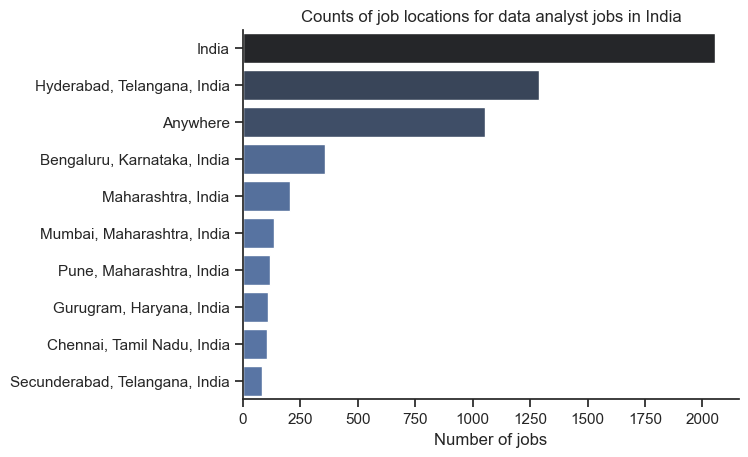

In [9]:
df_plot = df_DA_IND['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of job locations for data analyst jobs in India')
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.show()

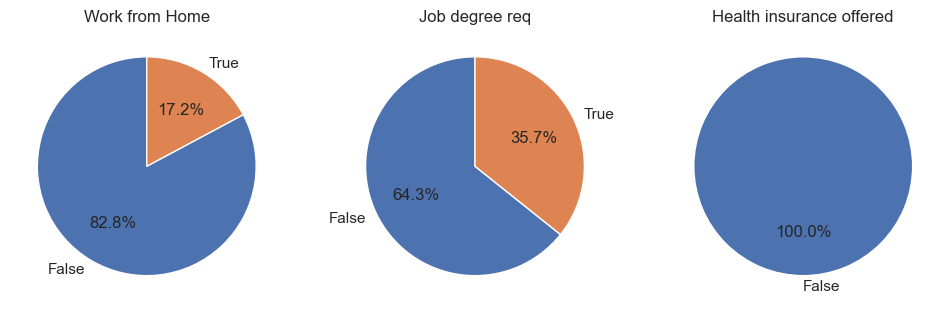

In [11]:
# Rewrite the above with a for loop
dict_column = {
    'job_work_from_home' : 'Work from Home',
    'job_no_degree_mention' : 'Job degree req',
    'job_health_insurance' : 'Health insurance offered'
}

fig, ax = plt.subplots(1, 3) 
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    counts = df_DA_IND[column].value_counts()
    ax[i].pie(counts, startangle=90, autopct='%1.1f%%', labels=counts.index)
    ax[i].set_title(title)

plt.show()

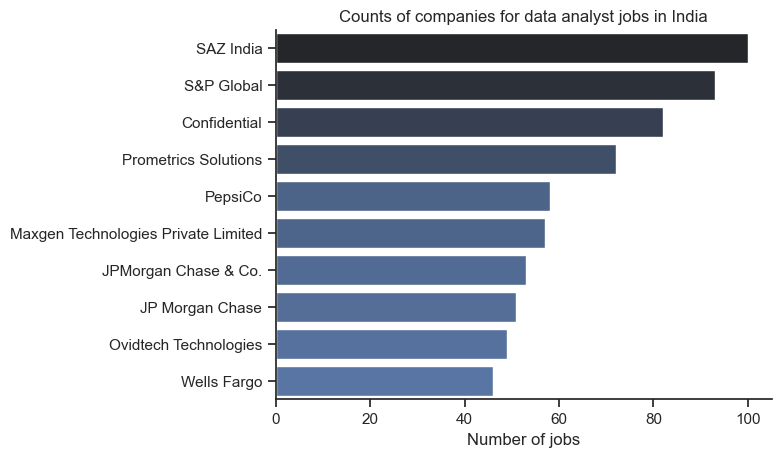

In [8]:
df_plot = df_DA_IND['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of companies for data analyst jobs in India')
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.show()